## FLAG-X workflow, unlabeled data

This notebook demonstrates how FLAG-X can be used to aid and accelerate manual gating of multiple samples. This can be used to efficiently obtain initial labels for the training of the supervised classification pipeline for fully automated gating. For details, refer to our preprint on [bioRxiv](https://doi.org/10.64898/2026.01.10.698765).

We use 5 samples (each downsampled to 10,000 per sample to reduce file sizes) of the Flowcyt benchmark dataset published by Bini *et al. (2024)* (see: [paper](https://proceedings.mlr.press/v248/bini24a.html), [data](https://cuicloud.unige.ch/index.php/s/55PHBLEynrp5pN8), [GitHub](https://github.com/VIPER-GENEVA/FlowCyt-Classification-Benchmark)) to demonstrate the following workflow:

1. Data loading
2. Data processing
3. SOM training
4. Dimensionality reduction
5. Export
6. Exemplary visualization of manual gating aided by learned 2D representations

**Disclaimer**: This notebook is intended as a template for adopting FLAG-X workflows to new datasets. The generated results are illustrative and should not be interpreted as a rigorous evaluation.


### Import packages and define paths

In [8]:
import os
import re
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import seaborn as sns

from flagx.io import FlowDataManager, export_to_fcs
from flagx.gating import SOMClassifier
from flagx.dimred import UMAP, TSNE

plt.style.use('default')

np.random.seed(42)

BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, 'data/flowcyt')
SAVE_PATH = os.path.join(BASE_DIR, 'results/unsupervised/flowcyt')
os.makedirs(SAVE_PATH, exist_ok=True)


### 1.) Data loading

Load the *FCS* files corresponding to patient samples using FLAG-X's ``FlowDataManager`` class.

Supported file formats are:
- *CSV*
- *FCS*, versions **3.1**, **3.0**, **2.0**
- *LMD*, containing an *FCS3.1*, *FCS3.0*, or *FCS2.0*-compliant part

Harmonization of channel names and channel ordering is only partially handled by FLAG-X. Each sample is expected to contain the same number of channels, in the same order, corresponding to the same markers. Slight differences in spelling of channel names across samples can be corrected automatically. If necessary, these properties must be ensured by hand.

For further details please refer to the [docs](https://flag-x.readthedocs.io/en/latest/).

In [9]:
# Instantiate the FlowDataManager
data_filenames = [f'Case_{i}.csv' for i in range(1, 6)]
fdm = FlowDataManager(
    data_file_names=data_filenames,
    data_file_path=DATA_PATH,
    save_path=None,
    verbosity=1
)

# Load the datafiles into memory
fdm.load_data_files_to_anndata()

# Check number of channels and order of channels
for adata in fdm.anndata_list_:
    print(f'# --- Filename: {adata.uns["filename"]}')
    print(f'# num channels: {adata.n_vars}')
    print(f'# channels names:\n{adata.var_names.tolist()}\n')


# --- Filename: Case_1.csv
# num channels: 16
# channels names:
['FS INT', 'SS PEAK', 'SS INT', 'SS TOF', 'FL1 INT_CD14-FITC', 'FL2 INT_CD19-PE', 'FL3 INT_CD13-ECD', 'FL4 INT_CD33-PC5.5', 'FL5 INT_CD34-PC7', 'FL6 INT_CD117-APC', 'FL7 INT_CD7-APC700', 'FL8 INT_CD16-APC750', 'FL9 INT_HLA-PB', 'FL10 INT_CD45-KO', 'TIME', 'label']

# --- Filename: Case_2.csv
# num channels: 16
# channels names:
['FS INT', 'SS PEAK', 'SS INT', 'SS TOF', 'FL1 INT_CD14-FITC', 'FL2 INT_CD19-PE', 'FL3 INT_CD13-ECD', 'FL4 INT_CD33-PC5.5', 'FL5 INT_CD34-PC7', 'FL6 INT_CD117-APC', 'FL7 INT_CD7-APC700', 'FL8 INT_CD16-APC750', 'FL9 INT_HLA-PB', 'FL10 INT_CD45-KO', 'TIME', 'label']

# --- Filename: Case_3.csv
# num channels: 16
# channels names:
['FS INT', 'SS PEAK', 'SS INT', 'SS TOF', 'FL1 INT_CD14-FITC', 'FL2 INT_CD19-PE', 'FL3 INT_CD13-ECD', 'FL4 INT_CD33-PC5.5', 'FL5 INT_CD34-PC7', 'FL6 INT_CD117-APC', 'FL7 INT_CD7-APC700', 'FL8 INT_CD16-APC750', 'FL9 INT_HLA-PB', 'FL10 INT_CD45-KO', 'TIME', 'label']

# --- File

### 2.) Data processing

# Channel names:
['FS INT', 'SS PEAK', 'SS INT', 'SS TOF', 'FL1 INT_CD14-FITC', 'FL2 INT_CD19-PE', 'FL3 INT_CD13-ECD', 'FL4 INT_CD33-PC5.5', 'FL5 INT_CD34-PC7', 'FL6 INT_CD117-APC', 'FL7 INT_CD7-APC700', 'FL8 INT_CD16-APC750', 'FL9 INT_HLA-PB', 'FL10 INT_CD45-KO', 'TIME', 'label']



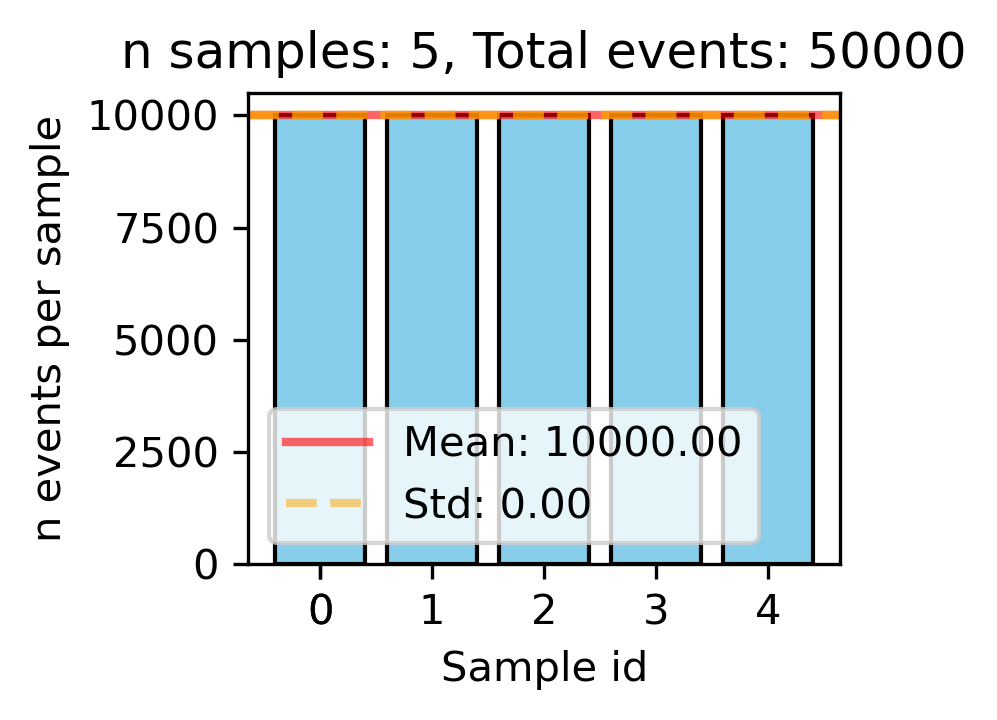

In [10]:

# Align channel names across samples, use 1st sample as reference
# Note: Harmonize channel names across samples by using the 1st file as reference for all others. Assume same channel order across samples.
fdm.align_channel_names(reference_channel_names=0)

# Check whether channel names were consistent across all samples
fdm.check_og_channel_names_df()

# Print the channel names
adata = fdm.anndata_list_[0]
print(f'# Channel names:\n{adata.var.index.tolist()}\n')

# Check the sample sizes
fdm.check_sample_sizes()
fig, ax = plt.subplots(figsize=(3, 2.5), dpi=300)
fdm.plot_sample_size_df(sample_size_df=fdm.sample_sizes_, ax=ax)
fig.tight_layout()
plt.show()
plt.close(fig)

# Apply compensation
# Note: The Flowcyt consists of compensated non-transformed data samples in CSV format.
# If uncompensated data in FCS or LMD format is loaded set compensate = True.
compensate = False
if compensate:
    fdm.sample_wise_compensation()
    print(f'# Compensation log:\n{fdm.compensation_log_}')

# Downsample to 5000 events per sample
# Note: Aggressive downsampling is done for faster SOM training and faster UMAP and t-SNE computation. In practice more events per sample should be retained.
fdm.sample_wise_downsampling(data_set='all', target_num_events=5000, stratified=False)

# Apply preprocessing transformation, choose arcsinh with a cofactor of 150, save non-transformed data to layer 'raw'
fdm.sample_wise_preprocessing(flavour='arcsinh', save_raw_to_layer='raw', cofactor=150)


### 3.) SOM training
Train the SOM component of the SOM classifier (unsupervised). A subset of channels is defined for model training. Here, a grid size of $10\times10$ is used, for larger datasets $25\times 25$ is recommended to achieve good separation of populations.

In [11]:
# Extract concatenated and shuffled data matrix for model training
# Note: Generate a Pytorch DataLoader with batch_size=-1 (meaning all events), and extract the 1st batch.
channels = [
    'FS INT', 'SS INT',
    'FL1 INT_CD14-FITC', 'FL2 INT_CD19-PE', 'FL3 INT_CD13-ECD', 'FL4 INT_CD33-PC5.5', 'FL5 INT_CD34-PC7', 'FL6 INT_CD117-APC', 'FL7 INT_CD7-APC700', 'FL8 INT_CD16-APC750', 'FL9 INT_HLA-PB', 'FL10 INT_CD45-KO'
]
data_loader = fdm.get_data_loader(
    data_set='all',
    channels=channels,
    batch_size=-1,
    shuffle=True,
    return_data_loader='np_array',
)
x_train = next(iter(data_loader))

# Create dummy label vector
y_train = np.full(x_train.shape[0], -999)

# Instantiate the SOM classifier
som_clf = SOMClassifier(
    som_topology='planar',
    som_grid_type='rectangular',
    som_dimensions=(10, 10),
    neighborhood='gaussian',
    gaussian_neighborhood_sigma=0.1,
    initialization='pca',
    n_epochs=100,
    radius_0=-0.5,
    radius_n=0.1,
    radius_cooling='exponential',
    learning_rate_0=0.1,
    learning_rate_n=0.001,
    learning_rate_decay='exponential',
    unlabeled_label=-999,
    verbosity=1
)

# Fit
som_clf.fit(X=x_train, y=y_train)



    100% [===================================================]


Time for epoch 1: 0.08389 Time for epoch 2: 0.04497 Time for epoch 3: 0.03522 Time for epoch 4: 0.04029 Time for epoch 5: 0.01933 Time for epoch 6: 0.02423 Time for epoch 7: 0.01354 Time for epoch 8: 0.01945 Time for epoch 9: 0.01369 Time for epoch 10: 0.01065 Time for epoch 11: 0.01437 Time for epoch 12: 0.01439 Time for epoch 13: 0.01077 Time for epoch 14: 0.01086 Time for epoch 15: 0.01062 Time for epoch 16: 0.01184 Time for epoch 17: 0.00956 Time for epoch 18: 0.01107 Time for epoch 19: 0.01009 Time for epoch 20: 0.009594 Time for epoch 21: 0.009875 Time for epoch 22: 0.008444 Time for epoch 23: 0.009029 Time for epoch 24: 0.00865 Time for epoch 25: 0.009736 Time for epoch 26: 0.008538 Time for epoch 27: 0.009107 Time for epoch 28: 0.008197 Time for epoch 29: 0.008531 Time for epoch 30: 0.00885 Time for epoch 31: 0.009197 Time for epoch 32: 0.00961 Time for epoch 33: 0.009415 Time for epoch 34: 0.009131 Time for epoch 35: 0.007938 Time for epoch 36: 0.008734 Time for epoch 37: 0.00

,som_topology,'planar'
,som_grid_type,'rectangular'
,som_dimensions,"(10, ...)"
,neighborhood,'gaussian'
,gaussian_neighborhood_sigma,0.1
,initialization,'pca'
,initial_codebook,None
,n_epochs,100
,radius_0,5.0
,radius_n,0.1
,radius_cooling,'exponential'


### 4.) Dimensionality reduction
The following representations of the training data in 2D space are computed:
- Mapping of individual events to their best matching unit in the SOM grid
- UMAP
- t-SNE

In [12]:

# Extract data matrices (arcsinh transformed and non-transformed) without shuffling and keep track of sample IDs
data_matrices = []
data_matrices_raw = []
sample_ids = []
filenames = []
for i, adata in enumerate(fdm.anndata_list_):
    data_matrices.append(adata[:, channels].X.copy())
    data_matrices_raw.append(adata[:, channels].layers['raw'].copy())
    sample_ids.append(np.full(adata.shape[0], i))
    filenames.append(adata.uns['filename'])
x_ordered = np.concatenate(data_matrices, axis=0)
x_ordered_raw = np.concatenate(data_matrices_raw, axis=0)
y_sample_id = np.concatenate(sample_ids, axis=0)

_, x_som, unit_ids, _ = som_clf.transform(x_ordered)

reducer_umap = UMAP(n_components=2, n_jobs=-1)
x_umap = reducer_umap.fit_transform(x_ordered)

reducer_tsne = TSNE(n_components=2, n_jobs=-1)
x_tsne = reducer_tsne.fit_transform(x_ordered)


### 5.) Export
Computed 2D representations are added to the raw training data and exported to FCS for manual gating using conventional flow cytometry software.

We recommend to scale the added columns (*kwargs:* ``scale_columns``, ``val_range``) to the same range as the FCM data, e.g. $2^{20}$ for Beckman Coulter Navios or $2^{18}$ for BD Cantos.
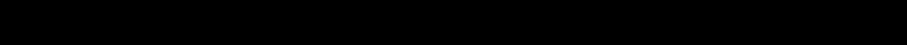
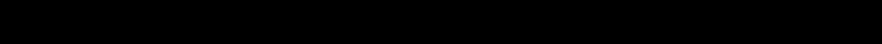

In [13]:

# Create dataframe with data to be exported and channel names as columns
x_ordered_raw_df = pd.DataFrame(x_ordered_raw, columns=channels)

# Export
export_to_fcs(
    data_list=[ad.AnnData(x_ordered_raw_df), ],
    sample_wise=True,
    add_columns=[
        [x_som[:, 0], ], [x_som[:, 1], ],
        [x_umap[:, 0], ], [x_umap[:, 1], ],
        [x_tsne[:, 0], ], [x_tsne[:, 1], ],
        [y_sample_id, ]
    ],
    add_columns_names=['SOM1', 'SOM2', 'UMAP1', 'UMAP2', 'TSNE1', 'TSNE2', 'sample_ID'],
    scale_columns=['SOM1', 'SOM2', 'UMAP1', 'UMAP2', 'TSNE1', 'TSNE2', 'sample_ID'],
    val_range=(0.0, 2.0**20),
    keep_unscaled=False,
    save_path=SAVE_PATH,
    save_filenames=['workflow_unsupervised_export.fcs', ]
)

# Additionally, save the mapping from filenames to sample IDs
df = pd.DataFrame({'filename': filenames, 'sample_ID': list(range(len(filenames)))})
df.to_csv(os.path.join(SAVE_PATH, 'workflow_unsupervised_export.csv'), index=False)


/home/paulm/miniforge3/envs/flagx-test/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


### Visualize results in Python

The main workflow is finished after the export of the annotated data samples. Inspection of the results, color coding, and manual gating is subsequently performed on the exported file, using conventional software for FCM analysis.

Added 2D representations (SOM, UMAP, t-SNE) and sample IDs are used to support the assignment of population labels.

For the sake of completeness, we visualize the results in Python. Shown population labels were provided by Bini *et al.* (2024).

We visualize the training data in (**A**) SOM, (**B**) UMAP, and (**C**) t-SNE representations space. Conventional marker-marker scatter plots for B cell gating are shown in (**D**-**F**).

**Note:** It can be seen that ground truth population labels correspond to distinct clusters in SOM, UMAP, and t-SNE representation space. This property can be used for delineating populations in unlabeled data.


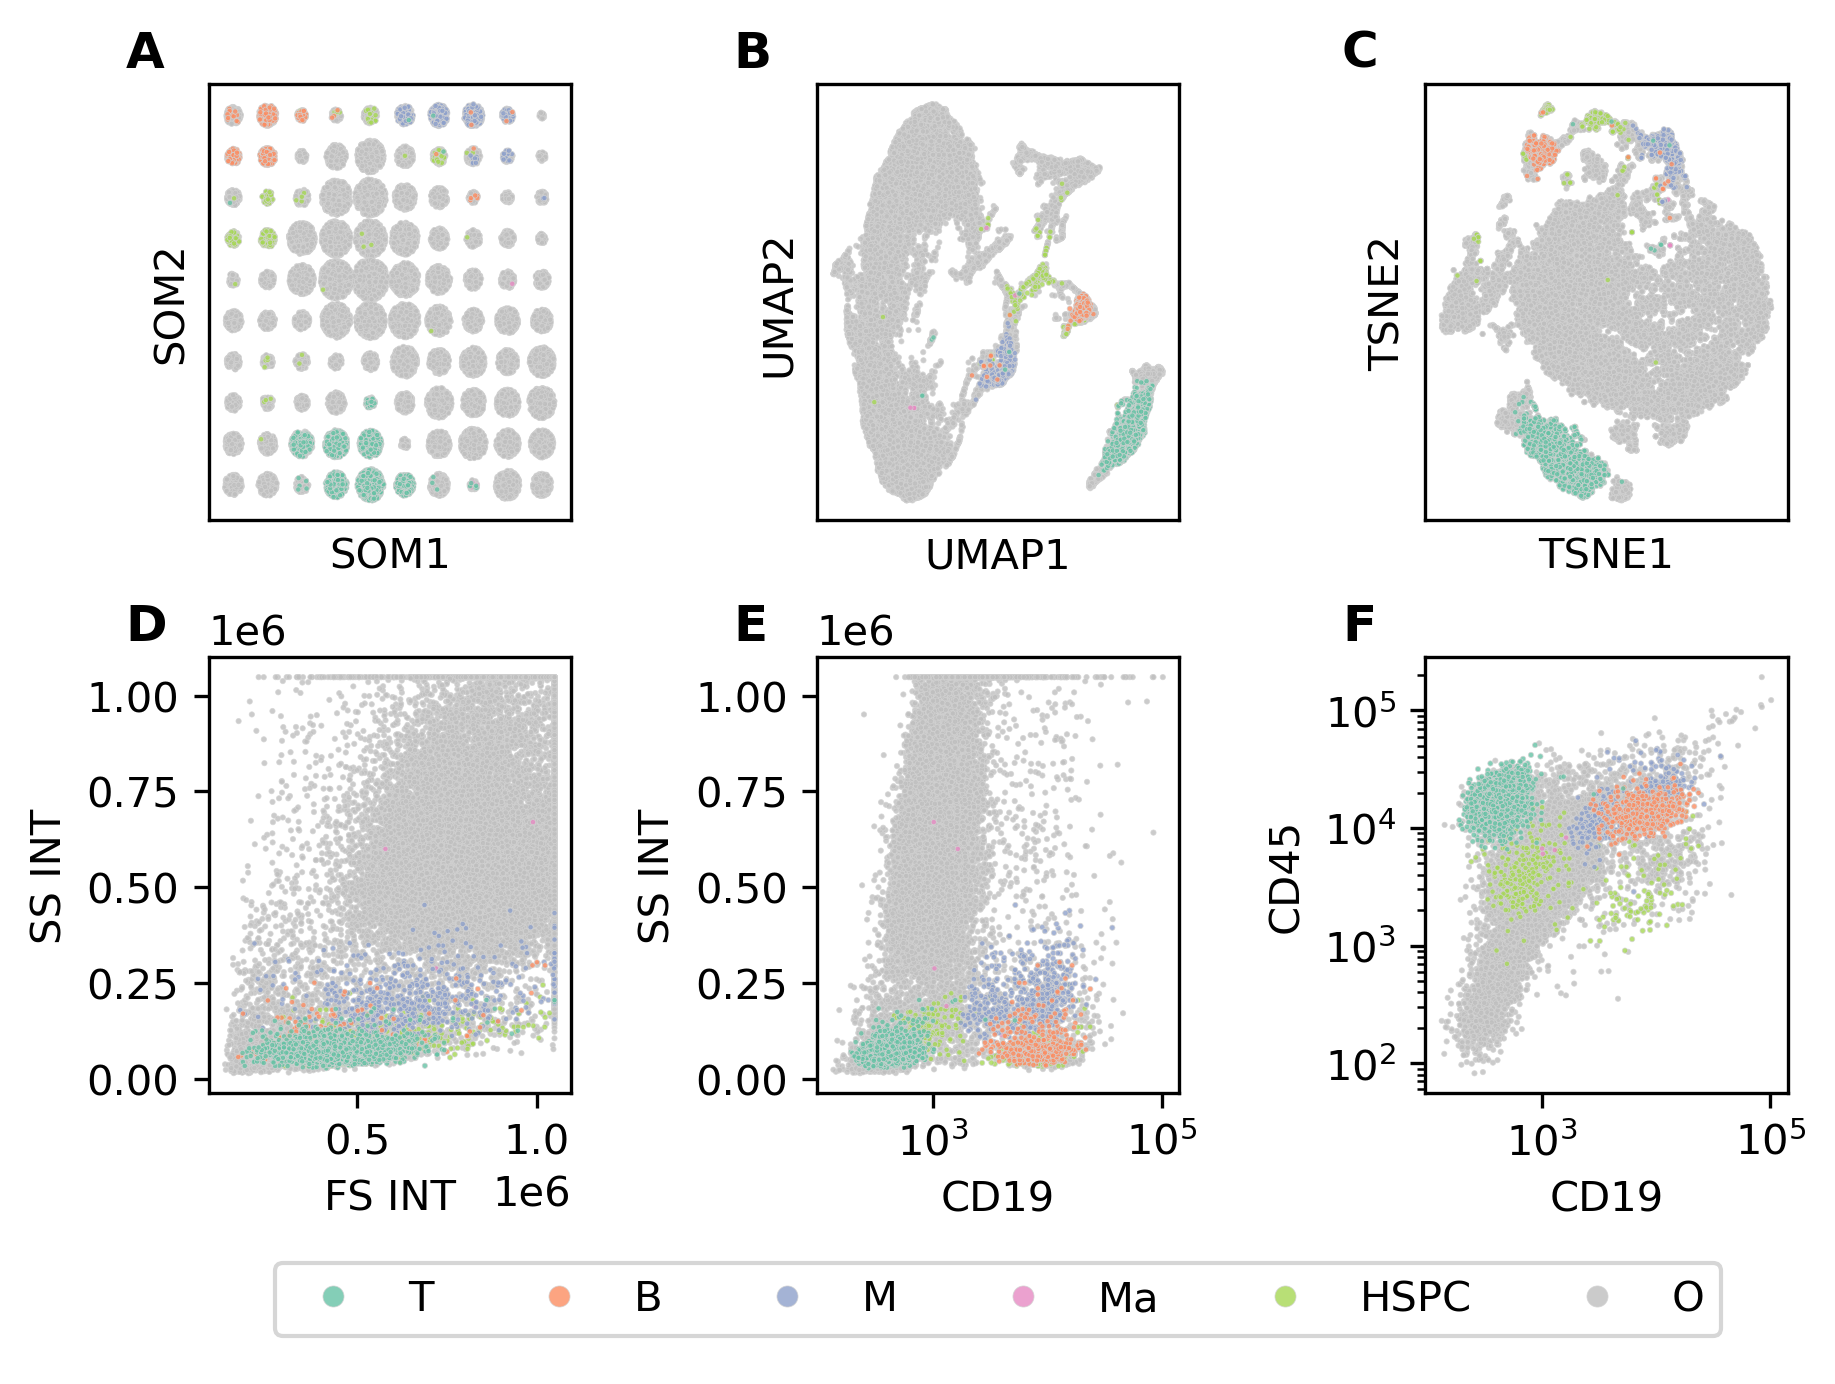

In [14]:
# Create df for plotting
plot_dfs = []
for adata in fdm.anndata_list_:
    df = pd.DataFrame(adata.layers['raw'], columns=adata.var.index)
    fn = adata.uns['filename']
    match = re.search(r'Case_(\d{1,2})\.csv$', fn)
    df['fn'] = fn
    df['sample_id'] = int(match.group(1))
    plot_dfs.append(df)

plot_df = pd.concat(plot_dfs, axis=0, ignore_index=True)

for dimred, x in zip(['SOM', 'UMAP', 'TSNE'], [x_som, x_umap, x_tsne]):
    for i in range(2):
        plot_df[ f'{dimred}_{i + 1}'] = x[:, i]

int_label_to_cell_type = {
        0: 'T',  # T lymphocyte
        1: 'B',  # B lymphocyte
        2: 'M',  # Monocyte
        3: 'Ma',  # Mast cell
        4: 'HSPC',  # Hematopoietic stem and progenitor cell
        5: 'O'  # Others
}
plot_df['cell_type'] = plot_df['label'].map(int_label_to_cell_type)

# Define palette
unique_cell_types = ['T', 'B', 'M', 'Ma', 'HSPC', 'O']
palette = {val: col for val, col in zip(unique_cell_types, sns.color_palette('Set2'))}
palette['O'] = (0.75, 0.75, 0.75)

plot_df = plot_df.sort_values(
    by='cell_type',
    key=lambda s: s.map({v: i for i, v in enumerate(unique_cell_types[::-1])}),
)

fig, axd = plt.subplot_mosaic(
    [
        list('ABC'),
        list('DEF'),
        ['L'] * 3,
    ],
    figsize=(6, 4.5),
    gridspec_kw={'height_ratios': [2/4.5, 2/4.5, 0.5/4.5]},
    dpi=300,
    constrained_layout=True,
)

marker_size = 1.6

for key, name in zip(list('ABC'), ['SOM', 'UMAP', 'TSNE']):

    ax = axd[key]
    sns.scatterplot(
        data=plot_df,
        x=f'{name}_1',
        y=f'{name}_2',
        hue='cell_type',
        hue_order=unique_cell_types,
        palette=palette,
        s=marker_size,
        edgecolors='lightgrey',
        linewidths=0.2,
        alpha=0.8,
        ax=ax
    )

    ax.set_xlabel(f'{name}1')
    ax.set_ylabel(f'{name}2')
    ax.set_xticks([])
    ax.set_yticks([])

# 'CD14', 'CD19', 'CD13', 'CD33', 'CD34', 'CD117', 'CD7', 'CD16', 'HLA', 'CD45'
marker_combinations = [('FS INT', 'SS INT'), ('FL2 INT_CD19-PE', 'SS INT'), ('FL2 INT_CD19-PE', 'FL10 INT_CD45-KO')]
marker_to_shorthand = {'FL2 INT_CD19-PE': 'CD19', 'FL10 INT_CD45-KO': 'CD45'}

for key, (marker0, marker1) in zip(list('DEF'), marker_combinations):

    ax = axd[key]
    sns.scatterplot(
        data=plot_df,
        x=marker0,
        y=marker1,
        hue='cell_type',
        hue_order=unique_cell_types,
        palette=palette,
        s=marker_size,
        edgecolors='lightgrey',
        linewidths=0.2,
        alpha=0.8,
        ax=ax
    )

    ax.set_xlabel(marker_to_shorthand.get(marker0, marker0))
    ax.set_ylabel(marker_to_shorthand.get(marker1, marker1))

    if marker0 not in ['FS INT', 'SS INT']:
        ax.set_xscale('log')
    if marker1 not in ['FS INT', 'SS INT']:
        ax.set_yscale('log')
    ax.grid(False)

handles, labels = axd['A'].get_legend_handles_labels()
axd['L'].legend(handles, labels, loc='center', markerscale=4.0, ncol=len(handles))
axd['L'].axis('off')
for key in list('ABCDEF'):
    axd[key].get_legend().remove()

for label, ax in axd.items():
    if label != 'L':
        trans = mtransforms.ScaledTranslation(-20 / 72, 7 / 72, fig.dpi_scale_trans)
        ax.text(0.0, 0.95, label, transform=ax.transAxes + trans, fontsize=12, va='bottom', fontfamily='sans-serif', fontweight='bold')

plt.show()
